In [5]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# Parámetros

In [6]:
cobre_capacidad = 500
aluminio_capacidad = 500

cantidad_recarga_maxima = 200
nivel_critico = 100
tiempo_espera_recarga_stock = 8 * 60   # 8 horas

unidades_stock_a_fabrica = 8

tiempo_medio_fabrica_rotor = 1 * 60
tiempo_desviacion_fabrica_rotor = 30
tiempo_min_fabrica_rotor = 30

tiempo_medio_fabrica_estator = 2 * 60
tiempo_desviacion_fabrica_estator = 30
tiempo_min_fabrica_estator = 30

robots_rotor = 2
robots_estator = 2

tiempo_medio_revision_rotor = 2 * 60
tiempo_desviacion_revision_rotor = 30
tiempo_min_revision_rotor = 30

tiempo_medio_revision_estator = 1 * 60
tiempo_desviacion_revision_estator = 30
tiempo_min_revision_estator = 30

operarios_rotor = 2
operarios_estator = 2

tiempo_medio_ensamblado = 2 * 60
tiempo_desviacion_ensamblado = 60
tiempo_min_ensamblado = 30

lineas_ensamblado = 3
almacen_capacidad = 20

TIEMPO_SIMULACION = 5 * 24 * 60
FABRICACION_ESPERADA = 500

# Modelo

In [7]:
def obtener_tiempo(minutos):
    minutos = int(minutos)
    return f"{(minutos // 60) % 24:02d}:{minutos % 60:02d} día {minutos // (60 * 24)}"

def tiempo_aleatorio(media, std, minimo):
    return max(minimo, int(random.gauss(media, std)))

def prob(t):
    return 1 / (1 + np.exp((t - 40) / 13))

In [8]:
ROTOR_COUNT = []
ROTOR_DEF_COUNT = []
ESTATOR_COUNT = []
ESTATOR_DEF_COUNT = []
NIVEL_ALUMINIO = []
NIVEL_COBRE = []
ESPERA_STOCK = []
MOTORES_TERMINADOS = []
ENVIOS_ALMACEN = []
VERBOSE = False


class LineaMontaje:
    def __init__(self, env: simpy.Environment):
        self.stock_cobre = simpy.Container(env, capacity=cobre_capacidad, init=cobre_capacidad)
        self.control_cobre = env.process(self.cobre_control(env))

        self.stock_aluminio = simpy.Container(env, capacity=aluminio_capacidad, init=aluminio_capacidad)
        self.control_aluminio = env.process(self.aluminio_control(env))

        self.fabrica_rotor = simpy.Resource(env, capacity=robots_rotor)
        self.fabrica_estator = simpy.Resource(env, capacity=robots_estator)

        self.revision_rotor = simpy.Resource(env, capacity=operarios_rotor)
        self.revision_estator = simpy.Resource(env, capacity=operarios_estator)

        self.pre_ensamblado_rotor = simpy.Container(env, capacity=lineas_ensamblado)
        self.pre_ensamblado_estator = simpy.Container(env, capacity=lineas_ensamblado)

        self.ensamblado = simpy.Resource(env, capacity=lineas_ensamblado)

        self.almacen = simpy.Container(env, capacity=almacen_capacidad)
        self.control_almacen = env.process(self.enviar_motores(env))

        self.pedido_cobre_en_curso = False
        self.pedido_aluminio_en_curso = False

    def cobre_control(self, env):
        while True:
            if self.stock_cobre.level < nivel_critico and not self.pedido_cobre_en_curso:
                self.pedido_cobre_en_curso = True

                if VERBOSE:
                    print(f"Pedido de cobre realizado a las {obtener_tiempo(env.now)}, nivel cobre: {self.stock_cobre.level}")

                yield env.timeout(tiempo_espera_recarga_stock)

                cantidad = min(cantidad_recarga_maxima, cobre_capacidad - self.stock_cobre.level)
                if cantidad > 0:
                    yield self.stock_cobre.put(cantidad)

                if VERBOSE:
                    print(f"Recarga de cobre completada a las {obtener_tiempo(env.now)}, nivel cobre: {self.stock_cobre.level}")

                self.pedido_cobre_en_curso = False

            yield env.timeout(1)

    def aluminio_control(self, env):
        while True:
            if self.stock_aluminio.level < nivel_critico and not self.pedido_aluminio_en_curso:
                self.pedido_aluminio_en_curso = True

                if VERBOSE:
                    print(f"Pedido de aluminio realizado a las {obtener_tiempo(env.now)}, nivel aluminio: {self.stock_aluminio.level}")

                yield env.timeout(tiempo_espera_recarga_stock)

                cantidad = min(cantidad_recarga_maxima, aluminio_capacidad - self.stock_aluminio.level)
                if cantidad > 0:
                    yield self.stock_aluminio.put(cantidad)

                if VERBOSE:
                    print(f"Recarga de aluminio completada a las {obtener_tiempo(env.now)}, nivel aluminio: {self.stock_aluminio.level}")

                self.pedido_aluminio_en_curso = False

            yield env.timeout(1)

    def medir_materiales(self, env):
        while True:
            NIVEL_ALUMINIO.append((env.now, self.stock_aluminio.level))
            NIVEL_COBRE.append((env.now, self.stock_cobre.level))
            yield env.timeout(60)

    def enviar_motores(self, env):
        while True:
            if self.almacen.level >= almacen_capacidad:
                cantidad = self.almacen.level
                ENVIOS_ALMACEN.append((env.now, cantidad))

                if VERBOSE:
                    print(f"Retirados {int(cantidad)} motores del almacén a las {obtener_tiempo(env.now)}")

                yield self.almacen.get(cantidad)

            yield env.timeout(1)

    def proceso_rotor(self, env):
        with self.fabrica_rotor.request() as req:
            yield req

            inicio_espera = env.now
            yield self.stock_cobre.get(unidades_stock_a_fabrica)
            yield self.stock_aluminio.get(unidades_stock_a_fabrica)
            fin_espera = env.now

            tiempo_espera = fin_espera - inicio_espera

            if tiempo_espera != 0:
                ESPERA_STOCK.append(tiempo_espera)

            tiempo_fabricacion = tiempo_aleatorio(
                tiempo_medio_fabrica_rotor,
                tiempo_desviacion_fabrica_rotor,
                tiempo_min_fabrica_rotor
            )
            yield env.timeout(tiempo_fabricacion)

            probabilidad_defecto = prob(tiempo_fabricacion)

        with self.revision_rotor.request() as req_rev:
            yield req_rev

            tiempo_revision = tiempo_aleatorio(
                tiempo_medio_revision_rotor,
                tiempo_desviacion_revision_rotor,
                tiempo_min_revision_rotor
            )
            yield env.timeout(tiempo_revision)

            if random.random() < probabilidad_defecto:
                ROTOR_DEF_COUNT.append(env.now)
                if VERBOSE:
                    print(f"Rotor descartado a las {obtener_tiempo(env.now)}")
            else:
                ROTOR_COUNT.append(env.now)
                yield self.pre_ensamblado_rotor.put(1)
                if VERBOSE:
                    print(f"Rotor preparado para ensamblado a las {obtener_tiempo(env.now)}")

    def proceso_estator(self, env):
        with self.fabrica_estator.request() as req:
            yield req

            inicio_espera = env.now
            yield self.stock_cobre.get(unidades_stock_a_fabrica)
            yield self.stock_aluminio.get(unidades_stock_a_fabrica)
            fin_espera = env.now

            tiempo_espera = fin_espera - inicio_espera

            if tiempo_espera != 0:
                ESPERA_STOCK.append(tiempo_espera)

            tiempo_fabricacion = tiempo_aleatorio(
                tiempo_medio_fabrica_estator,
                tiempo_desviacion_fabrica_estator,
                tiempo_min_fabrica_estator
            )
            yield env.timeout(tiempo_fabricacion)

            probabilidad_defecto = prob(tiempo_fabricacion)

        with self.revision_estator.request() as req_rev:
            yield req_rev

            tiempo_revision = tiempo_aleatorio(
                tiempo_medio_revision_estator,
                tiempo_desviacion_revision_estator,
                tiempo_min_revision_estator
            )
            yield env.timeout(tiempo_revision)


            if random.random() < probabilidad_defecto:
                ESTATOR_DEF_COUNT.append(env.now)
                if VERBOSE:
                    print(f"Estator descartado a las {obtener_tiempo(env.now)}")
            else:
                ESTATOR_COUNT.append(env.now)
                yield self.pre_ensamblado_estator.put(1)
                if VERBOSE:
                    print(f"Estator preparado para ensamblado a las {obtener_tiempo(env.now)}")

    def ensamblado_motores(self, env):
        while True:
            yield self.pre_ensamblado_rotor.get(1)
            yield self.pre_ensamblado_estator.get(1)

            with self.ensamblado.request() as req:
                yield req

                if VERBOSE:
                    print("Empieza el ensamblado")

                tiempo_ensamblado = tiempo_aleatorio(
                    tiempo_medio_ensamblado,
                    tiempo_desviacion_ensamblado,
                    tiempo_min_ensamblado
                )
                yield env.timeout(tiempo_ensamblado)

                yield self.almacen.put(1)
                MOTORES_TERMINADOS.append(env.now)

                if VERBOSE:
                    print(f"Motor enviado al almacén a las {obtener_tiempo(env.now)}, nivel almacén: {self.almacen.level}")

# Simulación

In [9]:
def ejecutar_simulacion(nivel_critico_valor=nivel_critico, verbose=False, semilla=None):
    global VERBOSE, nivel_critico
    global ROTOR_COUNT, ROTOR_DEF_COUNT, ESTATOR_COUNT, ESTATOR_DEF_COUNT
    global NIVEL_ALUMINIO, NIVEL_COBRE, ESPERA_STOCK
    global MOTORES_TERMINADOS, ENVIOS_ALMACEN

    VERBOSE = verbose
    nivel_critico = nivel_critico_valor

    if semilla is not None:
        random.seed(semilla)
        np.random.seed(semilla)

    ROTOR_COUNT = []
    ROTOR_DEF_COUNT = []
    ESTATOR_COUNT = []
    ESTATOR_DEF_COUNT = []
    NIVEL_ALUMINIO = []
    NIVEL_COBRE = []
    ESPERA_STOCK = []
    MOTORES_TERMINADOS = []
    ENVIOS_ALMACEN = []

    env = simpy.Environment()
    linea = LineaMontaje(env)

    def simulacion(env, linea):
        env.process(linea.medir_materiales(env))

        for _ in range(lineas_ensamblado):
            env.process(linea.ensamblado_motores(env))

        for _ in range(FABRICACION_ESPERADA):
            yield env.timeout(1)
            env.process(linea.proceso_rotor(env))
            env.process(linea.proceso_estator(env))

    env.process(simulacion(env, linea))
    env.run(until=TIEMPO_SIMULACION)

    total_rotores = len(ROTOR_COUNT) + len(ROTOR_DEF_COUNT)
    total_estatores = len(ESTATOR_COUNT) + len(ESTATOR_DEF_COUNT)

    porcentaje_rotor_def = 100 * len(ROTOR_DEF_COUNT) / total_rotores if total_rotores > 0 else 0
    porcentaje_estator_def = 100 * len(ESTATOR_DEF_COUNT) / total_estatores if total_estatores > 0 else 0
    espera_media_stock = np.mean(ESPERA_STOCK) if len(ESPERA_STOCK) > 0 else 0

    resultados = {
        "nivel_critico": nivel_critico_valor,
        "espera_media_stock": espera_media_stock,
        "rotores_buenos": len(ROTOR_COUNT),
        "rotores_defectuosos": len(ROTOR_DEF_COUNT),
        "estatores_buenos": len(ESTATOR_COUNT),
        "estatores_defectuosos": len(ESTATOR_DEF_COUNT),
        "porcentaje_rotor_def": porcentaje_rotor_def,
        "porcentaje_estator_def": porcentaje_estator_def,
        "motores_terminados": len(MOTORES_TERMINADOS),
        "envios_almacen": len(ENVIOS_ALMACEN),
        "historial_aluminio": NIVEL_ALUMINIO.copy(),
        "historial_cobre": NIVEL_COBRE.copy()
    }

    return resultados

In [10]:
resultado = ejecutar_simulacion(nivel_critico_valor=nivel_critico, verbose=True, semilla=123)

Rotor preparado para ensamblado a las 02:46 día 0
Estator preparado para ensamblado a las 02:50 día 0
Empieza el ensamblado
Rotor preparado para ensamblado a las 02:56 día 0
Estator preparado para ensamblado a las 03:09 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 04:58 día 0
Estator preparado para ensamblado a las 04:59 día 0
Rotor descartado a las 05:20 día 0
Rotor preparado para ensamblado a las 05:25 día 0
Empieza el ensamblado
Motor enviado al almacén a las 05:32 día 0, nivel almacén: 1
Motor enviado al almacén a las 06:15 día 0, nivel almacén: 2
Rotor preparado para ensamblado a las 06:51 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 06:55 día 0
Motor enviado al almacén a las 07:00 día 0, nivel almacén: 3
Rotor preparado para ensamblado a las 07:01 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 07:06 día 0
Rotor preparado para ensamblado a las 08:00 día 0
Empieza el ensamblado
Estator descartado a las 08:26 día 0
E

In [11]:
print("RESULTADOS DE UNA SIMULACIÓN")
print(f"Punto crítico: {resultado['nivel_critico']}")
print(f"Espera media por stock: {resultado['espera_media_stock']:.2f} minutos")
print(f"Rotores buenos: {resultado['rotores_buenos']}")
print(f"Rotores defectuosos: {resultado['rotores_defectuosos']}")
print(f"Estatores buenos: {resultado['estatores_buenos']}")
print(f"Estatores defectuosos: {resultado['estatores_defectuosos']}")
print(f"% rotores defectuosos: {resultado['porcentaje_rotor_def']:.2f}%")
print(f"% estatores defectuosos: {resultado['porcentaje_estator_def']:.2f}%")
print(f"Motores terminados: {resultado['motores_terminados']}")
print(f"Veces que se vació el almacén: {resultado['envios_almacen']}")

RESULTADOS DE UNA SIMULACIÓN
Punto crítico: 100
Espera media por stock: 185.42 minutos
Rotores buenos: 88
Rotores defectuosos: 33
Estatores buenos: 87
Estatores defectuosos: 5
% rotores defectuosos: 27.27%
% estatores defectuosos: 5.43%
Motores terminados: 86
Veces que se vació el almacén: 4


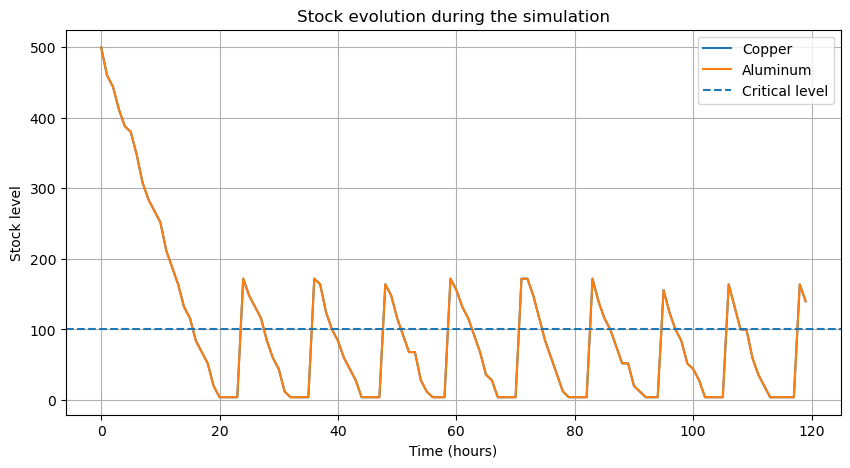

In [12]:
tiempos_al = [x[0] / 60 for x in resultado["historial_aluminio"]]
niveles_al = [x[1] for x in resultado["historial_aluminio"]]

tiempos_cu = [x[0] / 60 for x in resultado["historial_cobre"]]
niveles_cu = [x[1] for x in resultado["historial_cobre"]]

plt.figure(figsize=(10, 5))
plt.plot(tiempos_cu, niveles_cu, label="Copper")
plt.plot(tiempos_al, niveles_al, label="Aluminum")
plt.axhline(y=resultado["nivel_critico"], linestyle="--", label="Critical level")
plt.xlabel("Time (hours)")
plt.ylabel("Stock level")
plt.title("Stock evolution during the simulation")
plt.legend()
plt.grid(True)
plt.show()

# Optimizar el punto crítico

In [13]:
def optimizar_punto_critico(valores_criticos, repeticiones=10):
    resultados_opt = []

    for pc in valores_criticos:
        esperas = []
        motores = []
        defectos_rotor = []
        defectos_estator = []

        for rep in range(repeticiones):
            r = ejecutar_simulacion(
                nivel_critico_valor=pc,
                verbose=False,
                semilla=1000 + rep + pc
            )

            esperas.append(r["espera_media_stock"])
            motores.append(r["motores_terminados"])
            defectos_rotor.append(r["porcentaje_rotor_def"])
            defectos_estator.append(r["porcentaje_estator_def"])

        resultados_opt.append({
            "nivel_critico": pc,
            "espera_media": np.mean(esperas),
            "espera_std": np.std(esperas),
            "motores_media": np.mean(motores),
            "def_rotor_media": np.mean(defectos_rotor),
            "def_estator_media": np.mean(defectos_estator)
        })

        print(f"Punto crítico = {pc}, espera media = {np.mean(esperas):.2f} min")

    mejor_resultado = min(resultados_opt, key=lambda x: x["espera_media"])
    return resultados_opt, mejor_resultado

In [14]:
valores_criticos = list(range(50, 401, 25))
resultados_opt, mejor_resultado = optimizar_punto_critico(valores_criticos, repeticiones=10)

Punto crítico = 50, espera media = 319.58 min
Punto crítico = 75, espera media = 259.15 min
Punto crítico = 100, espera media = 196.90 min
Punto crítico = 125, espera media = 115.05 min
Punto crítico = 150, espera media = 70.83 min
Punto crítico = 175, espera media = 34.23 min
Punto crítico = 200, espera media = 20.64 min
Punto crítico = 225, espera media = 0.10 min
Punto crítico = 250, espera media = 0.00 min
Punto crítico = 275, espera media = 0.00 min
Punto crítico = 300, espera media = 0.00 min
Punto crítico = 325, espera media = 0.00 min
Punto crítico = 350, espera media = 0.00 min
Punto crítico = 375, espera media = 0.00 min
Punto crítico = 400, espera media = 0.00 min


In [15]:
resultado = ejecutar_simulacion(nivel_critico_valor=250, verbose=True, semilla=123)

Rotor preparado para ensamblado a las 02:46 día 0
Estator preparado para ensamblado a las 02:50 día 0
Empieza el ensamblado
Rotor preparado para ensamblado a las 02:56 día 0
Estator preparado para ensamblado a las 03:09 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 04:58 día 0
Estator preparado para ensamblado a las 04:59 día 0
Rotor descartado a las 05:20 día 0
Rotor preparado para ensamblado a las 05:25 día 0
Empieza el ensamblado
Motor enviado al almacén a las 05:32 día 0, nivel almacén: 1
Motor enviado al almacén a las 06:15 día 0, nivel almacén: 2
Rotor preparado para ensamblado a las 06:51 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 06:55 día 0
Motor enviado al almacén a las 07:00 día 0, nivel almacén: 3
Rotor preparado para ensamblado a las 07:01 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 07:06 día 0
Rotor preparado para ensamblado a las 08:00 día 0
Empieza el ensamblado
Estator descartado a las 08:26 día 0
E

In [16]:
print("RESULTADOS DE UNA SIMULACIÓN")
print(f"Punto crítico: {resultado['nivel_critico']}")
print(f"Espera media por stock: {resultado['espera_media_stock']:.2f} minutos")
print(f"Rotores buenos: {resultado['rotores_buenos']}")
print(f"Rotores defectuosos: {resultado['rotores_defectuosos']}")
print(f"Estatores buenos: {resultado['estatores_buenos']}")
print(f"Estatores defectuosos: {resultado['estatores_defectuosos']}")
print(f"% rotores defectuosos: {resultado['porcentaje_rotor_def']:.2f}%")
print(f"% estatores defectuosos: {resultado['porcentaje_estator_def']:.2f}%")
print(f"Motores terminados: {resultado['motores_terminados']}")
print(f"Veces que se vació el almacén: {resultado['envios_almacen']}")

RESULTADOS DE UNA SIMULACIÓN
Punto crítico: 250
Espera media por stock: 0.00 minutos
Rotores buenos: 87
Rotores defectuosos: 32
Estatores buenos: 91
Estatores defectuosos: 2
% rotores defectuosos: 26.89%
% estatores defectuosos: 2.15%
Motores terminados: 87
Veces que se vació el almacén: 4


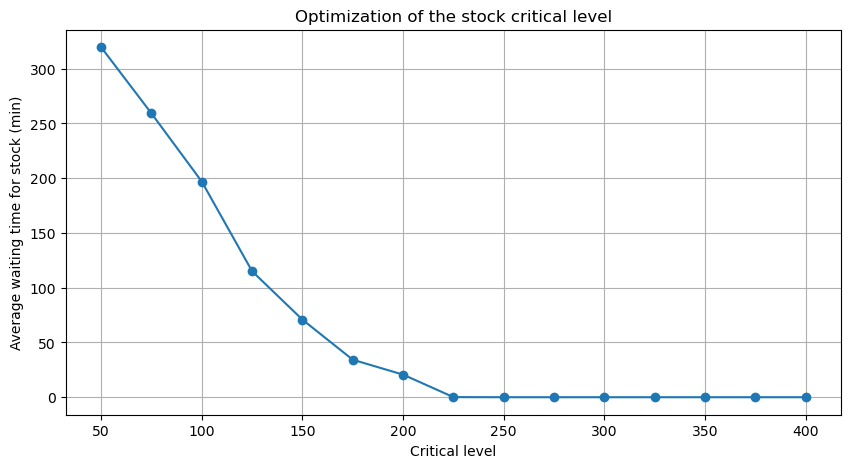

In [17]:
x = [r["nivel_critico"] for r in resultados_opt]
y = [r["espera_media"] for r in resultados_opt]

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o')
plt.xlabel("Critical level")
plt.ylabel("Average waiting time for stock (min)")
plt.title("Optimization of the stock critical level")
plt.grid(True)
plt.show()

In [32]:
import pandas as pd
df_resultados = pd.DataFrame(resultados_opt)
df_resultados.to_csv("./Datos/Transformados/Data_Science/resultados_optimizacion.csv", index=False)
print("CSV generado correctamente: resultados_optimizacion.csv")

CSV generado correctamente: resultados_optimizacion.csv


# Analizar otros parámetros 

In [19]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def ejecutar_simulacion_sensibilidad(
    nivel_critico_valor=250,
    tiempo_recarga_valor=8*60,
    cantidad_recarga_valor=200,
    consumo_valor=8,
    robots_rotor_valor=2,
    robots_estator_valor=2,
    verbose=False,
    semilla=None
):
    global VERBOSE
    global nivel_critico, tiempo_espera_recarga_stock, cantidad_recarga_maxima
    global unidades_stock_a_fabrica, robots_rotor, robots_estator
    global ROTOR_COUNT, ROTOR_DEF_COUNT, ESTATOR_COUNT, ESTATOR_DEF_COUNT
    global NIVEL_ALUMINIO, NIVEL_COBRE, ESPERA_STOCK
    global MOTORES_TERMINADOS, ENVIOS_ALMACEN

    VERBOSE = verbose

    # Cambiamos los parámetros del modelo
    nivel_critico = nivel_critico_valor
    tiempo_espera_recarga_stock = tiempo_recarga_valor
    cantidad_recarga_maxima = cantidad_recarga_valor
    unidades_stock_a_fabrica = consumo_valor
    robots_rotor = robots_rotor_valor
    robots_estator = robots_estator_valor

    if semilla is not None:
        random.seed(semilla)
        np.random.seed(semilla)

    # Reiniciar métricas
    ROTOR_COUNT = []
    ROTOR_DEF_COUNT = []
    ESTATOR_COUNT = []
    ESTATOR_DEF_COUNT = []
    NIVEL_ALUMINIO = []
    NIVEL_COBRE = []
    ESPERA_STOCK = []
    MOTORES_TERMINADOS = []
    ENVIOS_ALMACEN = []

    env = simpy.Environment()
    linea = LineaMontaje(env)

    def simulacion(env, linea):
        env.process(linea.medir_materiales(env))

        for _ in range(lineas_ensamblado):
            env.process(linea.ensamblado_motores(env))

        for _ in range(FABRICACION_ESPERADA):
            yield env.timeout(1)
            env.process(linea.proceso_rotor(env))
            env.process(linea.proceso_estator(env))

    env.process(simulacion(env, linea))
    env.run(until=TIEMPO_SIMULACION)

    total_rotores = len(ROTOR_COUNT) + len(ROTOR_DEF_COUNT)
    total_estatores = len(ESTATOR_COUNT) + len(ESTATOR_DEF_COUNT)

    porcentaje_rotor_def = 100 * len(ROTOR_DEF_COUNT) / total_rotores if total_rotores > 0 else 0
    porcentaje_estator_def = 100 * len(ESTATOR_DEF_COUNT) / total_estatores if total_estatores > 0 else 0
    espera_media_stock = np.mean(ESPERA_STOCK) if len(ESPERA_STOCK) > 0 else 0
    espera_max_stock = np.max(ESPERA_STOCK) if len(ESPERA_STOCK) > 0 else 0
    num_esperas = sum(1 for x in ESPERA_STOCK if x > 0)

    resultados = {
        "nivel_critico": nivel_critico_valor,
        "tiempo_recarga": tiempo_recarga_valor,
        "cantidad_recarga": cantidad_recarga_valor,
        "consumo": consumo_valor,
        "robots_rotor": robots_rotor_valor,
        "robots_estator": robots_estator_valor,
        "espera_media_stock": espera_media_stock,
        "espera_max_stock": espera_max_stock,
        "num_esperas": num_esperas,
        "rotores_buenos": len(ROTOR_COUNT),
        "rotores_defectuosos": len(ROTOR_DEF_COUNT),
        "estatores_buenos": len(ESTATOR_COUNT),
        "estatores_defectuosos": len(ESTATOR_DEF_COUNT),
        "porcentaje_rotor_def": porcentaje_rotor_def,
        "porcentaje_estator_def": porcentaje_estator_def,
        "motores_terminados": len(MOTORES_TERMINADOS),
        "envios_almacen": len(ENVIOS_ALMACEN),
        "historial_aluminio": NIVEL_ALUMINIO.copy(),
        "historial_cobre": NIVEL_COBRE.copy()
    }

    return resultados

In [21]:
N_SIM = 10
nivel_critico_fijo = 250

In [22]:
valores_tiempo = [4*60, 6*60, 8*60, 10*60, 12*60]
resultados_tiempo = []

for t in valores_tiempo:
    esperas = []

    for rep in range(N_SIM):
        r = ejecutar_simulacion_sensibilidad(
            nivel_critico_valor=nivel_critico_fijo,
            tiempo_recarga_valor=t,
            cantidad_recarga_valor=200,
            consumo_valor=8,
            robots_rotor_valor=2,
            robots_estator_valor=2,
            verbose=False,
            semilla=1000 + rep
        )
        esperas.append(r["espera_media_stock"])

    resultados_tiempo.append(np.mean(esperas))

print("Tiempo de recarga vs espera media")
for t, r in zip(valores_tiempo, resultados_tiempo):
    print(f"{t/60:.0f} horas -> {r:.2f} min")

Tiempo de recarga vs espera media
4 horas -> 0.00 min
6 horas -> 0.00 min
8 horas -> 0.00 min
10 horas -> 90.10 min
12 horas -> 193.86 min


In [23]:
valores_cantidad = [100, 150, 200, 250, 300]
resultados_cantidad = []

for c in valores_cantidad:
    esperas = []

    for rep in range(N_SIM):
        r = ejecutar_simulacion_sensibilidad(
            nivel_critico_valor=nivel_critico_fijo,
            tiempo_recarga_valor=8*60,
            cantidad_recarga_valor=c,
            consumo_valor=8,
            robots_rotor_valor=2,
            robots_estator_valor=2,
            verbose=False,
            semilla=2000 + rep
        )
        esperas.append(r["espera_media_stock"])

    resultados_cantidad.append(np.mean(esperas))

print("Cantidad de recarga vs espera media")
for c, r in zip(valores_cantidad, resultados_cantidad):
    print(f"{c} unidades -> {r:.2f} min")

Cantidad de recarga vs espera media
100 unidades -> 212.64 min
150 unidades -> 94.94 min
200 unidades -> 0.00 min
250 unidades -> 0.00 min
300 unidades -> 0.00 min


In [24]:
valores_consumo = [6, 8, 10, 12]
resultados_consumo = []

for cons in valores_consumo:
    esperas = []

    for rep in range(N_SIM):
        r = ejecutar_simulacion_sensibilidad(
            nivel_critico_valor=nivel_critico_fijo,
            tiempo_recarga_valor=8*60,
            cantidad_recarga_valor=200,
            consumo_valor=cons,
            robots_rotor_valor=2,
            robots_estator_valor=2,
            verbose=False,
            semilla=3000 + rep
        )
        esperas.append(r["espera_media_stock"])

    resultados_consumo.append(np.mean(esperas))

print("Consumo por operación vs espera media")
for cons, r in zip(valores_consumo, resultados_consumo):
    print(f"{cons} unidades -> {r:.2f} min")

Consumo por operación vs espera media
6 unidades -> 0.00 min
8 unidades -> 1.30 min
10 unidades -> 74.46 min
12 unidades -> 127.96 min


In [25]:
valores_robots = [1, 2, 3]
resultados_robots = []

for rob in valores_robots:
    esperas = []

    for rep in range(N_SIM):
        r = ejecutar_simulacion_sensibilidad(
            nivel_critico_valor=nivel_critico_fijo,
            tiempo_recarga_valor=8*60,
            cantidad_recarga_valor=200,
            consumo_valor=8,
            robots_rotor_valor=rob,
            robots_estator_valor=rob,
            verbose=False,
            semilla=4000 + rep
        )
        esperas.append(r["espera_media_stock"])

    resultados_robots.append(np.mean(esperas))

print("Número de robots vs espera media")
for rob, r in zip(valores_robots, resultados_robots):
    print(f"{rob} robots -> {r:.2f} min")

Número de robots vs espera media
1 robots -> 0.00 min
2 robots -> 0.90 min
3 robots -> 131.29 min


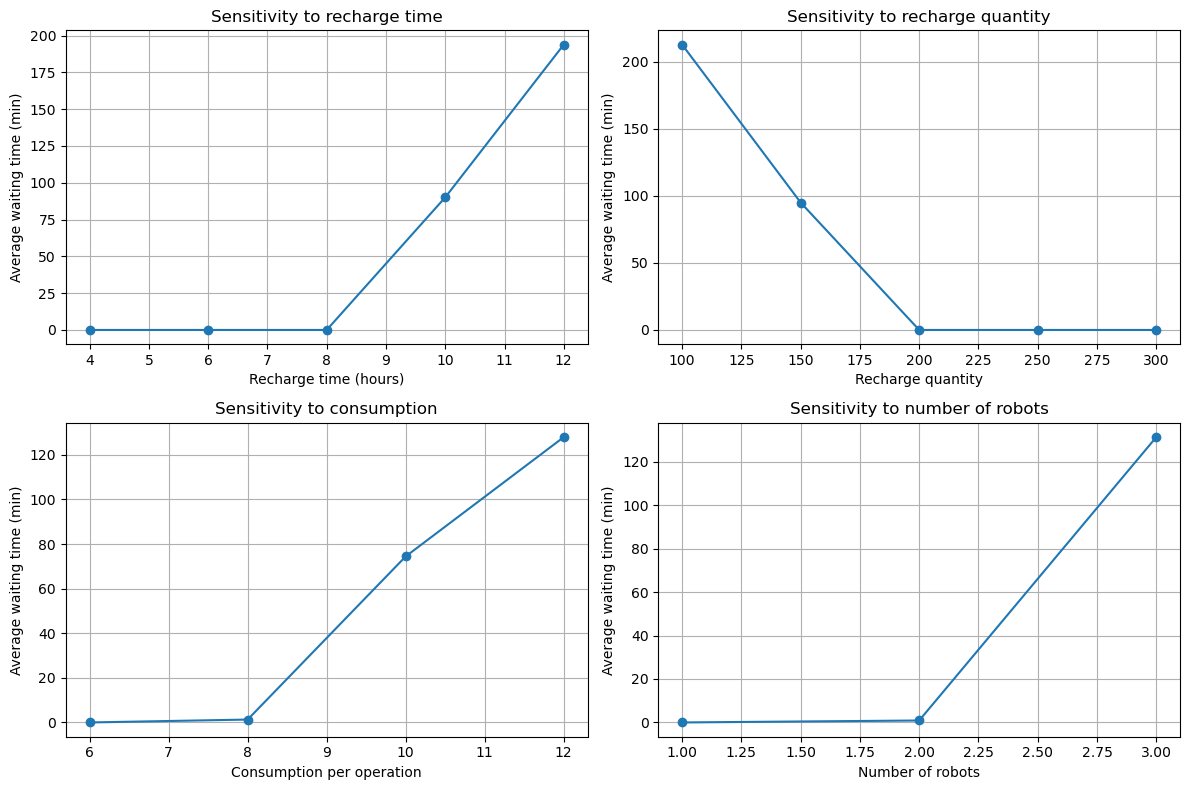

In [26]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot([t/60 for t in valores_tiempo], resultados_tiempo, marker='o')
plt.xlabel("Recharge time (hours)")
plt.ylabel("Average waiting time (min)")
plt.title("Sensitivity to recharge time")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(valores_cantidad, resultados_cantidad, marker='o')
plt.xlabel("Recharge quantity")
plt.ylabel("Average waiting time (min)")
plt.title("Sensitivity to recharge quantity")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(valores_consumo, resultados_consumo, marker='o')
plt.xlabel("Consumption per operation")
plt.ylabel("Average waiting time (min)")
plt.title("Sensitivity to consumption")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(valores_robots, resultados_robots, marker='o')
plt.xlabel("Number of robots")
plt.ylabel("Average waiting time (min)")
plt.title("Sensitivity to number of robots")
plt.grid(True)

plt.tight_layout()
plt.show()

### Hacer simulacion con los parámetros optimos. 

In [27]:
cobre_capacidad = 500
aluminio_capacidad = 500

cantidad_recarga_maxima = 200 # Cambio a 250 para poner el óptimo
nivel_critico = 250 # Cambio a 250 para poner el óptimo
tiempo_espera_recarga_stock = 8 * 60   # 8 para poner el óptimo

unidades_stock_a_fabrica = 6 # Cambio a 6 para poner el óptimo

tiempo_medio_fabrica_rotor = 1 * 60
tiempo_desviacion_fabrica_rotor = 30
tiempo_min_fabrica_rotor = 30

tiempo_medio_fabrica_estator = 2 * 60
tiempo_desviacion_fabrica_estator = 30
tiempo_min_fabrica_estator = 30

robots_rotor = 2
robots_estator = 2

tiempo_medio_revision_rotor = 2 * 60
tiempo_desviacion_revision_rotor = 30
tiempo_min_revision_rotor = 30

tiempo_medio_revision_estator = 1 * 60
tiempo_desviacion_revision_estator = 30
tiempo_min_revision_estator = 30

operarios_rotor = 2
operarios_estator = 2

tiempo_medio_ensamblado = 2 * 60
tiempo_desviacion_ensamblado = 60
tiempo_min_ensamblado = 30

lineas_ensamblado = 3
almacen_capacidad = 20

TIEMPO_SIMULACION = 5 * 24 * 60
FABRICACION_ESPERADA = 500

In [28]:
ROTOR_COUNT = []
ROTOR_DEF_COUNT = []
ESTATOR_COUNT = []
ESTATOR_DEF_COUNT = []
NIVEL_ALUMINIO = []
NIVEL_COBRE = []
ESPERA_STOCK = []
MOTORES_TERMINADOS = []
ENVIOS_ALMACEN = []
VERBOSE = False


class LineaMontaje:
    def __init__(self, env: simpy.Environment):
        self.stock_cobre = simpy.Container(env, capacity=cobre_capacidad, init=cobre_capacidad)
        self.control_cobre = env.process(self.cobre_control(env))

        self.stock_aluminio = simpy.Container(env, capacity=aluminio_capacidad, init=aluminio_capacidad)
        self.control_aluminio = env.process(self.aluminio_control(env))

        self.fabrica_rotor = simpy.Resource(env, capacity=robots_rotor)
        self.fabrica_estator = simpy.Resource(env, capacity=robots_estator)

        self.revision_rotor = simpy.Resource(env, capacity=operarios_rotor)
        self.revision_estator = simpy.Resource(env, capacity=operarios_estator)

        self.pre_ensamblado_rotor = simpy.Container(env, capacity=lineas_ensamblado)
        self.pre_ensamblado_estator = simpy.Container(env, capacity=lineas_ensamblado)

        self.ensamblado = simpy.Resource(env, capacity=lineas_ensamblado)

        self.almacen = simpy.Container(env, capacity=almacen_capacidad)
        self.control_almacen = env.process(self.enviar_motores(env))

        self.pedido_cobre_en_curso = False
        self.pedido_aluminio_en_curso = False

    def cobre_control(self, env):
        while True:
            if self.stock_cobre.level < nivel_critico and not self.pedido_cobre_en_curso:
                self.pedido_cobre_en_curso = True

                if VERBOSE:
                    print(f"Pedido de cobre realizado a las {obtener_tiempo(env.now)}, nivel cobre: {self.stock_cobre.level}")

                yield env.timeout(tiempo_espera_recarga_stock)

                cantidad = min(cantidad_recarga_maxima, cobre_capacidad - self.stock_cobre.level)
                if cantidad > 0:
                    yield self.stock_cobre.put(cantidad)

                if VERBOSE:
                    print(f"Recarga de cobre completada a las {obtener_tiempo(env.now)}, nivel cobre: {self.stock_cobre.level}")

                self.pedido_cobre_en_curso = False

            yield env.timeout(1)

    def aluminio_control(self, env):
        while True:
            if self.stock_aluminio.level < nivel_critico and not self.pedido_aluminio_en_curso:
                self.pedido_aluminio_en_curso = True

                if VERBOSE:
                    print(f"Pedido de aluminio realizado a las {obtener_tiempo(env.now)}, nivel aluminio: {self.stock_aluminio.level}")

                yield env.timeout(tiempo_espera_recarga_stock)

                cantidad = min(cantidad_recarga_maxima, aluminio_capacidad - self.stock_aluminio.level)
                if cantidad > 0:
                    yield self.stock_aluminio.put(cantidad)

                if VERBOSE:
                    print(f"Recarga de aluminio completada a las {obtener_tiempo(env.now)}, nivel aluminio: {self.stock_aluminio.level}")

                self.pedido_aluminio_en_curso = False

            yield env.timeout(1)

    def medir_materiales(self, env):
        while True:
            NIVEL_ALUMINIO.append((env.now, self.stock_aluminio.level))
            NIVEL_COBRE.append((env.now, self.stock_cobre.level))
            yield env.timeout(60)

    def enviar_motores(self, env):
        while True:
            if self.almacen.level >= almacen_capacidad:
                cantidad = self.almacen.level
                ENVIOS_ALMACEN.append((env.now, cantidad))

                if VERBOSE:
                    print(f"Retirados {int(cantidad)} motores del almacén a las {obtener_tiempo(env.now)}")

                yield self.almacen.get(cantidad)

            yield env.timeout(1)

    def proceso_rotor(self, env):
        with self.fabrica_rotor.request() as req:
            yield req

            inicio_espera = env.now
            yield self.stock_cobre.get(unidades_stock_a_fabrica)
            yield self.stock_aluminio.get(unidades_stock_a_fabrica)
            fin_espera = env.now

            tiempo_espera = fin_espera - inicio_espera

            if tiempo_espera != 0:
                ESPERA_STOCK.append(tiempo_espera)

            tiempo_fabricacion = tiempo_aleatorio(
                tiempo_medio_fabrica_rotor,
                tiempo_desviacion_fabrica_rotor,
                tiempo_min_fabrica_rotor
            )
            yield env.timeout(tiempo_fabricacion)

            probabilidad_defecto = prob(tiempo_fabricacion)

        with self.revision_rotor.request() as req_rev:
            yield req_rev

            tiempo_revision = tiempo_aleatorio(
                tiempo_medio_revision_rotor,
                tiempo_desviacion_revision_rotor,
                tiempo_min_revision_rotor
            )
            yield env.timeout(tiempo_revision)

            if random.random() < probabilidad_defecto:
                ROTOR_DEF_COUNT.append(env.now)
                if VERBOSE:
                    print(f"Rotor descartado a las {obtener_tiempo(env.now)}")
            else:
                ROTOR_COUNT.append(env.now)
                yield self.pre_ensamblado_rotor.put(1)
                if VERBOSE:
                    print(f"Rotor preparado para ensamblado a las {obtener_tiempo(env.now)}")

    def proceso_estator(self, env):
        with self.fabrica_estator.request() as req:
            yield req

            inicio_espera = env.now
            yield self.stock_cobre.get(unidades_stock_a_fabrica)
            yield self.stock_aluminio.get(unidades_stock_a_fabrica)
            fin_espera = env.now

            tiempo_espera = fin_espera - inicio_espera

            if tiempo_espera != 0:
                ESPERA_STOCK.append(tiempo_espera)

            tiempo_fabricacion = tiempo_aleatorio(
                tiempo_medio_fabrica_estator,
                tiempo_desviacion_fabrica_estator,
                tiempo_min_fabrica_estator
            )
            yield env.timeout(tiempo_fabricacion)

            probabilidad_defecto = prob(tiempo_fabricacion)

        with self.revision_estator.request() as req_rev:
            yield req_rev

            tiempo_revision = tiempo_aleatorio(
                tiempo_medio_revision_estator,
                tiempo_desviacion_revision_estator,
                tiempo_min_revision_estator
            )
            yield env.timeout(tiempo_revision)


            if random.random() < probabilidad_defecto:
                ESTATOR_DEF_COUNT.append(env.now)
                if VERBOSE:
                    print(f"Estator descartado a las {obtener_tiempo(env.now)}")
            else:
                ESTATOR_COUNT.append(env.now)
                yield self.pre_ensamblado_estator.put(1)
                if VERBOSE:
                    print(f"Estator preparado para ensamblado a las {obtener_tiempo(env.now)}")

    def ensamblado_motores(self, env):
        while True:
            yield self.pre_ensamblado_rotor.get(1)
            yield self.pre_ensamblado_estator.get(1)

            with self.ensamblado.request() as req:
                yield req

                if VERBOSE:
                    print("Empieza el ensamblado")

                tiempo_ensamblado = tiempo_aleatorio(
                    tiempo_medio_ensamblado,
                    tiempo_desviacion_ensamblado,
                    tiempo_min_ensamblado
                )
                yield env.timeout(tiempo_ensamblado)

                yield self.almacen.put(1)
                MOTORES_TERMINADOS.append(env.now)

                if VERBOSE:
                    print(f"Motor enviado al almacén a las {obtener_tiempo(env.now)}, nivel almacén: {self.almacen.level}")

In [29]:
def ejecutar_simulacion(nivel_critico_valor=nivel_critico, verbose=False, semilla=None):
    global VERBOSE, nivel_critico
    global ROTOR_COUNT, ROTOR_DEF_COUNT, ESTATOR_COUNT, ESTATOR_DEF_COUNT
    global NIVEL_ALUMINIO, NIVEL_COBRE, ESPERA_STOCK
    global MOTORES_TERMINADOS, ENVIOS_ALMACEN

    VERBOSE = verbose
    nivel_critico = nivel_critico_valor

    if semilla is not None:
        random.seed(semilla)
        np.random.seed(semilla)

    ROTOR_COUNT = []
    ROTOR_DEF_COUNT = []
    ESTATOR_COUNT = []
    ESTATOR_DEF_COUNT = []
    NIVEL_ALUMINIO = []
    NIVEL_COBRE = []
    ESPERA_STOCK = []
    MOTORES_TERMINADOS = []
    ENVIOS_ALMACEN = []

    env = simpy.Environment()
    linea = LineaMontaje(env)

    def simulacion(env, linea):
        env.process(linea.medir_materiales(env))

        for _ in range(lineas_ensamblado):
            env.process(linea.ensamblado_motores(env))

        for _ in range(FABRICACION_ESPERADA):
            yield env.timeout(1)
            env.process(linea.proceso_rotor(env))
            env.process(linea.proceso_estator(env))

    env.process(simulacion(env, linea))
    env.run(until=TIEMPO_SIMULACION)

    total_rotores = len(ROTOR_COUNT) + len(ROTOR_DEF_COUNT)
    total_estatores = len(ESTATOR_COUNT) + len(ESTATOR_DEF_COUNT)

    porcentaje_rotor_def = 100 * len(ROTOR_DEF_COUNT) / total_rotores if total_rotores > 0 else 0
    porcentaje_estator_def = 100 * len(ESTATOR_DEF_COUNT) / total_estatores if total_estatores > 0 else 0
    espera_media_stock = np.mean(ESPERA_STOCK) if len(ESPERA_STOCK) > 0 else 0

    resultados = {
        "nivel_critico": nivel_critico_valor,
        "espera_media_stock": espera_media_stock,
        "rotores_buenos": len(ROTOR_COUNT),
        "rotores_defectuosos": len(ROTOR_DEF_COUNT),
        "estatores_buenos": len(ESTATOR_COUNT),
        "estatores_defectuosos": len(ESTATOR_DEF_COUNT),
        "porcentaje_rotor_def": porcentaje_rotor_def,
        "porcentaje_estator_def": porcentaje_estator_def,
        "motores_terminados": len(MOTORES_TERMINADOS),
        "envios_almacen": len(ENVIOS_ALMACEN),
        "historial_aluminio": NIVEL_ALUMINIO.copy(),
        "historial_cobre": NIVEL_COBRE.copy()
    }

    return resultados

In [30]:
resultado = ejecutar_simulacion(nivel_critico_valor=nivel_critico, verbose=True, semilla=123)

Rotor preparado para ensamblado a las 02:46 día 0
Estator preparado para ensamblado a las 02:50 día 0
Empieza el ensamblado
Rotor preparado para ensamblado a las 02:56 día 0
Estator preparado para ensamblado a las 03:09 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 04:58 día 0
Estator preparado para ensamblado a las 04:59 día 0
Rotor descartado a las 05:20 día 0
Rotor preparado para ensamblado a las 05:25 día 0
Empieza el ensamblado
Motor enviado al almacén a las 05:32 día 0, nivel almacén: 1
Motor enviado al almacén a las 06:15 día 0, nivel almacén: 2
Rotor preparado para ensamblado a las 06:51 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 06:55 día 0
Motor enviado al almacén a las 07:00 día 0, nivel almacén: 3
Rotor preparado para ensamblado a las 07:01 día 0
Empieza el ensamblado
Estator preparado para ensamblado a las 07:06 día 0
Rotor preparado para ensamblado a las 08:00 día 0
Empieza el ensamblado
Estator descartado a las 08:26 día 0
E

In [31]:
print("RESULTADOS DE UNA SIMULACIÓN")
print(f"Punto crítico: {resultado['nivel_critico']}")
print(f"Espera media por stock: {resultado['espera_media_stock']:.2f} minutos")
print(f"Rotores buenos: {resultado['rotores_buenos']}")
print(f"Rotores defectuosos: {resultado['rotores_defectuosos']}")
print(f"Estatores buenos: {resultado['estatores_buenos']}")
print(f"Estatores defectuosos: {resultado['estatores_defectuosos']}")
print(f"% rotores defectuosos: {resultado['porcentaje_rotor_def']:.2f}%")
print(f"% estatores defectuosos: {resultado['porcentaje_estator_def']:.2f}%")
print(f"Motores terminados: {resultado['motores_terminados']}")
print(f"Veces que se vació el almacén: {resultado['envios_almacen']}")

RESULTADOS DE UNA SIMULACIÓN
Punto crítico: 250
Espera media por stock: 0.00 minutos
Rotores buenos: 87
Rotores defectuosos: 32
Estatores buenos: 91
Estatores defectuosos: 2
% rotores defectuosos: 26.89%
% estatores defectuosos: 2.15%
Motores terminados: 87
Veces que se vació el almacén: 4


# Limitaciones del modelo

A pesar de la utilidad del modelo desarrollado para analizar el comportamiento de la línea de producción, es importante señalar que se trata de una representación simplificada de un sistema real, por lo que sus resultados deben interpretarse con cautela.

En primer lugar, el modelo se basa en datos simulados y parámetros prefijados, no calibrados con información real, lo que limita su capacidad predictiva. Asimismo, elementos como el tiempo de recarga o la cantidad de reposición se consideran deterministas, sin incorporar la variabilidad que caracteriza a los sistemas logísticos reales.

Por otro lado, el modelo no contempla averías, mantenimientos ni interrupciones operativas, asumiendo una disponibilidad continua de los recursos productivos. Además, la simulación parte de condiciones iniciales ideales, con niveles de stock completos y sin acumulación previa de retrasos, lo que puede introducir sesgos en los resultados iniciales.

La política de inventario implementada se basa en un enfoque sencillo de punto crítico, sin considerar estrategias más avanzadas de gestión, mientras que el sistema de control de calidad se modela de forma simplificada, sin recoger todos los factores que influyen en la aparición de defectos en un entorno real.

Finalmente, el análisis se centra en indicadores operativos, sin incorporar una dimensión económica, y los resultados están sujetos a la variabilidad inherente a los procesos aleatorios utilizados en la simulación.

En conjunto, estas limitaciones no invalidan el modelo, pero sí delimitan su alcance, siendo necesario complementarlo con datos reales y modelos más complejos para su aplicación en entornos industriales reales.
